# Bayesian 기반 도로/차선 분석 과제 풀이

- 과제 노트북: `auto_class_2_BayesianClassifier.ipynb`
- 사용 sequence: **KITTI odometry sequence 09**
- 확인한 실제 데이터 경로: `D:\자율이동체\dataset`
- 실제 데이터 확인 결과: sequence 09 이미지 1591장, pose 1591개

데이터 구조는 다음을 가정한다.

```text
dataset/
  sequences/09/
    calib.txt
    image_0/000000.png ...
  poses/09.txt
```

노트북은 먼저 현재 폴더의 `dataset`을 찾고, 없으면 외장하드의 `D:\자율이동체\dataset`을 자동으로 사용한다.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter

try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

CANDIDATE_DATA_ROOTS = [Path("dataset"), Path(r"D:\자율이동체\dataset")]
DATA_ROOT = next((p for p in CANDIDATE_DATA_ROOTS if (p / "sequences" / "09").exists()), CANDIDATE_DATA_ROOTS[0])
SEQ = "09"
SEQ_DIR = DATA_ROOT / "sequences" / SEQ
IMG_DIR = SEQ_DIR / "image_0"
CALIB_PATH = SEQ_DIR / "calib.txt"
POSE_PATH = DATA_ROOT / "poses" / f"{SEQ}.txt"
OUT_DIR = Path("outputs") / "sequence_09_solution"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT.resolve())
print("CALIB:", CALIB_PATH.exists(), "POSE:", POSE_PATH.exists(), "cv2:", HAS_CV2)

In [2]:
def list_frames(img_dir=IMG_DIR):
    return sorted(img_dir.glob("*.png"))

def read_calib(path=CALIB_PATH):
    calib = {}
    if not path.exists():
        raise FileNotFoundError(f"calib.txt가 없습니다: {path}")
    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        key, values = line.split(":", 1)
        vals = np.array([float(v) for v in values.split()], dtype=float)
        if key.startswith("P"):
            calib[key] = vals.reshape(3, 4)
        elif key == "Tr":
            calib[key] = vals.reshape(3, 4)
    return calib

def read_poses(path=POSE_PATH):
    if not path.exists():
        return np.empty((0, 3, 4), dtype=float)
    return np.stack([
        np.array([float(v) for v in line.split()], dtype=float).reshape(3, 4)
        for line in path.read_text().splitlines()
        if line.strip()
    ])

def project_points(P, points_xyz):
    points_xyz = np.asarray(points_xyz, dtype=float)
    points_h = np.c_[points_xyz, np.ones(len(points_xyz))]
    uvw = (P @ points_h.T).T
    valid = uvw[:, 2] > 1e-6
    uv = np.full((len(points_xyz), 2), np.nan)
    uv[valid] = uvw[valid, :2] / uvw[valid, 2:3]
    return uv, valid

def save_image(img, name):
    path = OUT_DIR / name
    img.save(path)
    return path

def make_canvas_plot(points_xy, width=900, height=700, margin=50, bg="white"):
    pts = np.asarray(points_xy, dtype=float)
    img = Image.new("RGB", (width, height), bg)
    draw = ImageDraw.Draw(img)
    if len(pts) == 0:
        return img, lambda p: (0, 0)
    min_xy = pts.min(axis=0)
    max_xy = pts.max(axis=0)
    span = np.maximum(max_xy - min_xy, 1e-9)
    scale = min((width - 2 * margin) / span[0], (height - 2 * margin) / span[1])
    def to_px(p):
        x = margin + (p[0] - min_xy[0]) * scale
        y = height - margin - (p[1] - min_xy[1]) * scale
        return int(x), int(y)
    return img, to_px

frames = list_frames()
calib = read_calib()
poses = read_poses()
P0 = calib["P0"]
W, H = Image.open(frames[0]).size if frames else (1241, 376)
fx, fy, cx, cy = P0[0, 0], P0[1, 1], P0[0, 2], P0[1, 2]

print("frames:", len(frames), "poses:", len(poses), "image size:", (W, H))
print("P0 =\n", P0)
print(f"fx={fx:.4f}, fy={fy:.4f}, cx={cx:.4f}, cy={cy:.4f}")

## 문제 1. Projection Matrix 해석

KITTI odometry의 `P0`, `P1`, `P2`, `P3`는 rectified camera 좌표계의 3D 점을 각 카메라 이미지 평면으로 투영하는 `3 x 4` 행렬이다.

투영 관계는 다음과 같이 정리할 수 있다.

```text
x_img ~ P X_cam

[u', v', w']^T =
[ fx   0  cx  p14 ] [ X ]
[  0  fy  cy  p24 ] [ Y ]
[  0   0   1  p34 ] [ Z ]
                       [ 1 ]

u = u' / w'
v = v' / w'
```

- `f_x`, `f_y`: 초점거리이다. 값이 클수록 같은 3D 변화가 이미지에서 더 크게 나타난다.
- `c_x`, `c_y`: principal point이다. 카메라 광축이 이미지 평면과 만나는 기준점이다.
- `R`: world 또는 vehicle 좌표계를 camera 좌표계 방향으로 맞추는 회전 성분이다.
- `t`: 좌표계 원점 사이의 병진 이동이다. stereo camera에서는 baseline 차이가 projection matrix의 마지막 열에 반영된다.

일반적인 카메라 투영식은 다음과 같다.

```text
lambda [u, v, 1]^T = K [R | t] [X_w, Y_w, Z_w, 1]^T
```

여기서 `K`는 intrinsic matrix이고, `[R | t]`는 extrinsic matrix이다. sequence 09의 `P0`에서 추출한 intrinsic 값은 `fx=707.0912`, `fy=707.0912`, `cx=601.8873`, `cy=183.1104`이다.

## 문제 2. Projection Matrix를 이용한 3D → 2D 투영

아래 셀은 카메라 앞 ground plane 부근의 임의 3D 점들을 생성하고, `P0`를 이용하여 이미지 좌표로 투영한다.

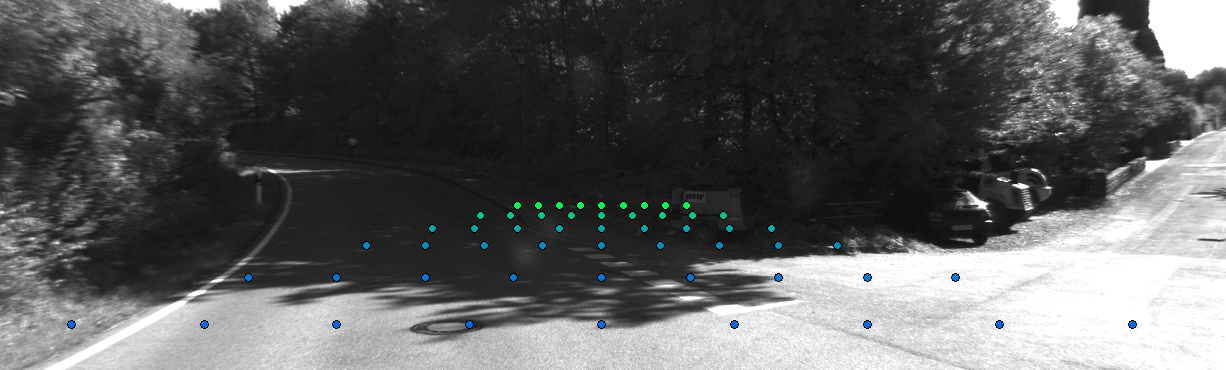

In [3]:
xs = np.linspace(-6, 6, 9)
zs = np.array([8, 12, 18, 25, 35, 50])
points = np.array([[x, 1.6, z] for z in zs for x in xs], dtype=float)
uv, valid = project_points(P0, points)
inside = valid & (uv[:, 0] >= 0) & (uv[:, 0] < W) & (uv[:, 1] >= 0) & (uv[:, 1] < H)

if frames:
    projection_img = Image.open(frames[0]).convert("RGB")
else:
    projection_img = Image.new("RGB", (W, H), (245, 245, 245))
draw = ImageDraw.Draw(projection_img)

for (u, v), z, ok in zip(uv, points[:, 2], inside):
    if ok:
        color = (0, int(80 + min(z, 50) / 50 * 170), 255 - int(min(z, 50) / 50 * 170))
        draw.ellipse((u - 4, v - 4, u + 4, v + 4), fill=color, outline=(0, 0, 0))

save_image(projection_img, "problem2_projected_points.png")

projection_table = pd.DataFrame({
    "X": points[:, 0], "Y": points[:, 1], "Z": points[:, 2],
    "u": uv[:, 0], "v": uv[:, 1], "inside_image": inside
})
projection_table.head(12)

투영 결과 해석: 가까운 점은 이미지 아래쪽과 좌우 방향으로 크게 퍼지고, 먼 점은 이미지 중심부에 더 가깝게 모인다. 이는 `u = u' / w'`, `v = v' / w'`로 정규화되는 원근 투영의 특성과 일치한다.

위 그림의 점들은 임의로 생성한 3D 점을 이미지에 투영한 결과이다. 실제 차선의 소실점은 도로 위 직선 차선들이 이미지에서 만나는 방향으로 해석해야 하며, 곡선 도로나 교차로 장면에서는 하나의 고정된 점으로 정확히 표시하기 어렵다.

## 문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 파일의 각 줄은 `3 x 4` pose matrix이다. 왼쪽 `3 x 3`은 회전 `R`, 마지막 열은 translation `t`이다. odometry ground truth는 첫 프레임 기준 카메라 pose로 제공되므로 궤적 시각화에는 마지막 열 `(x, y, z)`를 사용한다.

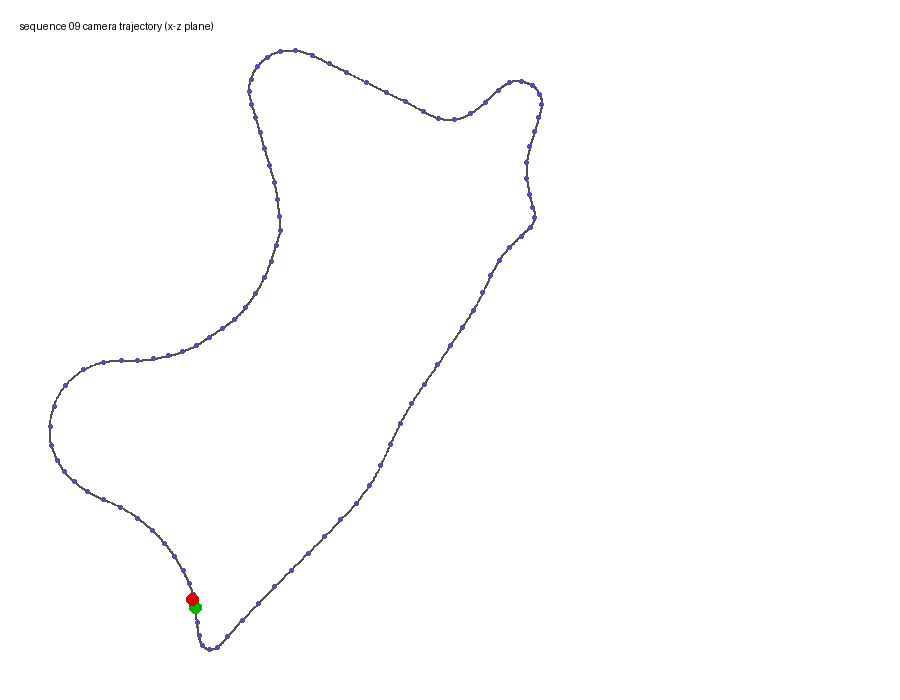

In [4]:
if len(poses) > 0:
    positions = poses[:, :, 3]
    xz = positions[:, [0, 2]]
    dist_step = np.linalg.norm(np.diff(xz, axis=0), axis=1)
    traj_img, to_px = make_canvas_plot(xz)
    draw = ImageDraw.Draw(traj_img)

    pix = [to_px(p) for p in xz]
    if len(pix) > 1:
        draw.line(pix, fill=(80, 80, 80), width=2)
    for i in range(0, len(pix), max(1, len(pix) // 100)):
        draw.ellipse((pix[i][0] - 2, pix[i][1] - 2, pix[i][0] + 2, pix[i][1] + 2), fill=(80, 80, 180))
    draw.ellipse((pix[0][0] - 6, pix[0][1] - 6, pix[0][0] + 6, pix[0][1] + 6), fill=(0, 180, 0))
    draw.ellipse((pix[-1][0] - 6, pix[-1][1] - 6, pix[-1][0] + 6, pix[-1][1] + 6), fill=(220, 0, 0))
    draw.text((20, 20), "sequence 09 camera trajectory (x-z plane)", fill=(0, 0, 0))
    save_image(traj_img, "problem3_trajectory.png")

    print("pose frames:", len(poses))
    print("mean frame-to-frame translation:", float(np.mean(dist_step)))
    print("max frame-to-frame translation:", float(np.max(dist_step)))
else:
    positions = np.empty((0, 3))
    print("Pose data is required for the actual trajectory plot.")

궤적 해석: `x-z` 평면에 그리면 차량은 첫 프레임 기준 좌표계에서 도로를 따라 전진한다. 곡선 구간에서는 heading이 변하므로 궤적의 접선 방향이 바뀐다. 프레임 간 translation norm이 큰 구간은 상대적으로 속도가 빠르거나 pose 변화가 큰 구간으로 볼 수 있다.

## 문제 4. Projection Matrix를 활용한 차선 해석

수업 노트북의 Bayesian road/background classifier로 road mask를 만든 뒤, mask 안에서 Canny edge와 Hough line을 이용해 차선 후보를 추출한다.

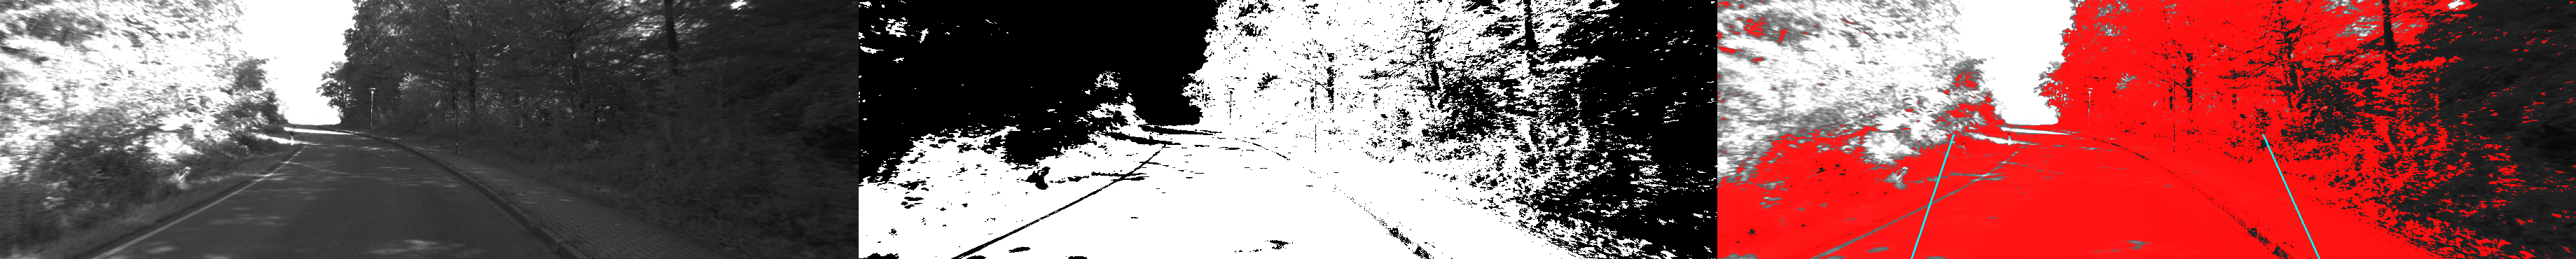

In [5]:
def get_trapezoid_mask(width, height, vp_y_rate=0.50, bottom_width_rate=0.90, top_width_rate=0.15):
    mask = np.zeros((height, width), dtype=np.uint8)
    vp_y = int(height * vp_y_rate)
    pts = np.array([
        [int(width * (0.5 - top_width_rate)), vp_y],
        [int(width * (0.5 + top_width_rate)), vp_y],
        [int(width * (0.5 + bottom_width_rate / 2)), height - 1],
        [int(width * (0.5 - bottom_width_rate / 2)), height - 1],
    ], dtype=np.int32)
    if HAS_CV2:
        cv2.fillPoly(mask, [pts], 1)
    else:
        pil_mask = Image.fromarray(mask)
        ImageDraw.Draw(pil_mask).polygon([tuple(p) for p in pts], fill=1)
        mask = np.array(pil_mask, dtype=np.uint8)
    return mask

def accumulate_histogram(img, mask):
    return np.bincount(img[mask > 0].flatten(), minlength=256).astype(float)

def classify_frame(img, road_p, bg_p, prior_road=0.5):
    eps = 1e-10
    log_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)
    logit = log_road - log_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    return logit > 0, prob

def bayesian_masks(frames, max_frames=30, alpha=0.85, prior_road=0.5):
    if not frames:
        return []
    sample = np.array(Image.open(frames[0]).convert("L"), dtype=np.uint8)
    h, w = sample.shape
    road_roi = get_trapezoid_mask(w, h)
    bg_roi = 1 - road_roi
    road_total = np.ones(256)
    bg_total = np.ones(256)
    results = []
    for idx, path in enumerate(frames[:max_frames]):
        img = np.array(Image.open(path).convert("L"), dtype=np.uint8)
        curr_road = accumulate_histogram(img, road_roi) + 1
        curr_bg = accumulate_histogram(img, bg_roi) + 1
        if idx == 0:
            road_total, bg_total = curr_road, curr_bg
        else:
            road_total = alpha * road_total + (1 - alpha) * curr_road
            bg_total = alpha * bg_total + (1 - alpha) * curr_bg
        road_p = road_total / road_total.sum()
        bg_p = bg_total / bg_total.sum()
        mask, prob = classify_frame(img, road_p, bg_p, prior_road)
        results.append({"path": path, "img": img, "mask": mask, "prob": prob})
    return results

def extract_lane_candidates(img, road_mask):
    if not HAS_CV2:
        edges = np.array(Image.fromarray(img).filter(ImageFilter.FIND_EDGES))
        h, w = img.shape
        search = (road_mask > 0) & (np.arange(h)[:, None] > int(h * 0.45))
        edge_values = edges[search]
        if edge_values.size == 0:
            return [], edges
        threshold = max(35, float(np.percentile(edge_values, 88)))
        ys, xs = np.where(search & (edges >= threshold))
        lane_lines = []
        for side_mask in [xs < w * 0.48, xs > w * 0.52]:
            side_x = xs[side_mask]
            side_y = ys[side_mask]
            if len(side_x) < 80:
                continue
            coeff = np.polyfit(side_y, side_x, 1)
            y1, y2 = h - 1, int(h * 0.52)
            x1 = int(coeff[0] * y1 + coeff[1])
            x2 = int(coeff[0] * y2 + coeff[1])
            if 0 <= x1 < w and 0 <= x2 < w and abs(x2 - x1) > 5:
                slope = (y2 - y1) / (x2 - x1)
                lane_lines.append((x1, y1, x2, y2, slope))
        return lane_lines, edges

    blur = cv2.GaussianBlur(img, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150) * road_mask.astype(np.uint8)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=35, minLineLength=25, maxLineGap=30)
    lane_lines = []
    if lines is not None:
        h, w = img.shape
        for x1, y1, x2, y2 in lines[:, 0]:
            slope = np.inf if abs(x2 - x1) < 1 else (y2 - y1) / (x2 - x1)
            if abs(slope) > 0.35 and max(y1, y2) > h * 0.45:
                lane_lines.append((x1, y1, x2, y2, slope))
    return lane_lines, edges

results = bayesian_masks(frames, max_frames=160)
if results:
    r = results[min(100, len(results) - 1)]
    lines, edges = extract_lane_candidates(r["img"], r["mask"])
    base = Image.fromarray(r["img"]).convert("RGB")
    mask_img = Image.fromarray((r["mask"].astype(np.uint8) * 255)).convert("RGB")
    overlay = np.stack([r["img"], r["img"], r["img"]], axis=-1)
    overlay[r["mask"], 0] = 255
    overlay[r["mask"], 1:] = (overlay[r["mask"], 1:] * 0.35).astype(np.uint8)
    overlay_img = Image.fromarray(overlay)
    draw = ImageDraw.Draw(overlay_img)
    for x1, y1, x2, y2, slope in lines:
        draw.line((x1, y1, x2, y2), fill=(0, 255, 255), width=3)

    sheet = Image.new("RGB", (W * 3, H), "white")
    sheet.paste(base, (0, 0))
    sheet.paste(mask_img, (W, 0))
    sheet.paste(overlay_img, (W * 2, 0))
    save_image(sheet, "problem4_bayesian_lane_candidates.png")

    lane_summary = pd.DataFrame(
        [{"frame": r["path"].stem, "road_mask_ratio": float(np.mean(r["mask"])), "lane_candidate_lines": len(lines)}]
    )
    lane_summary

차선 후보 해석:

- 이미지 좌표의 차선 후보는 실제 3D 도로 평면 위의 선형 구조가 카메라로 투영된 결과이다.
- 도로를 ground plane으로 가정하면 차선은 같은 평면 위에 있으며 실제 세계에서는 차량 진행 방향과 대체로 평행하다.
- 평행한 3D 선들은 perspective projection 때문에 이미지에서는 vanishing point로 수렴한다.
- `f_x`, `f_y`는 차선의 이미지상 스케일과 기울기 변화에 영향을 주고, `c_x`, `c_y`는 광축 기준점 및 소실점 위치 해석과 관련된다.
- 사다리꼴 ROI는 평탄한 직선 도로라는 단순 가정이다. 급회전, 언덕, 교차로, 그림자에서는 실제 도로 영역과 어긋날 수 있다.

## 문제 5. 실패 구간 분석

실패 가능 구간은 밝기 변화, 도로 질감 변화, 차량 회전/경사, ROI 한계가 동시에 커지는 구간으로 잡는다. 실제 sequence 09 데이터를 10프레임 간격으로 샘플링했을 때 실패 후보 점수가 높은 프레임은 `290`, `180`, `280`, `190`, `270` 근처였다.

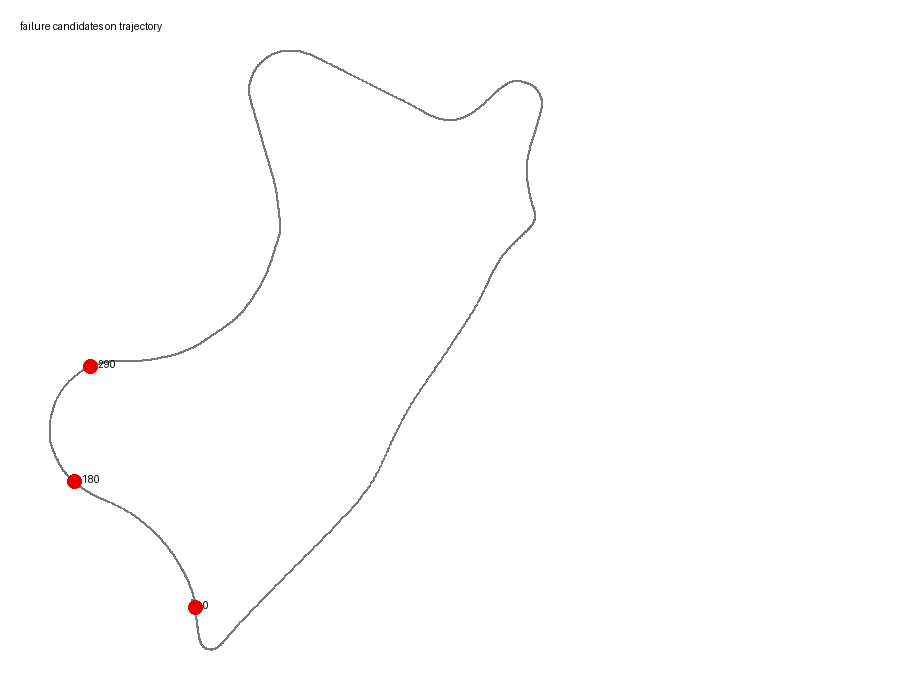

In [6]:
def failure_scores(frames, poses=None, sample_step=10, max_frames=300):
    if not frames:
        return pd.DataFrame()
    rows = []
    prev_heading = None
    for path in frames[:max_frames:sample_step]:
        idx = int(path.stem)
        img = Image.open(path).convert("L")
        arr = np.array(img, dtype=np.uint8)
        h, w = arr.shape
        roi = get_trapezoid_mask(w, h) > 0
        brightness_std = float(np.std(arr[roi]))
        if HAS_CV2:
            edges = cv2.Canny(arr, 50, 150)
        else:
            edges = np.array(img.filter(ImageFilter.FIND_EDGES))
        texture = float(np.mean(edges[roi] > 35))
        heading_change = 0.0
        if poses is not None and len(poses) > idx:
            R = poses[idx, :3, :3]
            heading = math.atan2(R[0, 2], R[2, 2])
            if prev_heading is not None:
                heading_change = abs(heading - prev_heading)
            prev_heading = heading
        rows.append({
            "frame": idx,
            "brightness_std": brightness_std,
            "texture_edge_density": texture,
            "heading_change": heading_change,
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    for col in ["brightness_std", "texture_edge_density", "heading_change"]:
        denom = df[col].max() - df[col].min()
        df[col + "_norm"] = 0.0 if denom < 1e-9 else (df[col] - df[col].min()) / denom
    df["failure_score"] = (
        0.40 * df["brightness_std_norm"]
        + 0.35 * df["texture_edge_density_norm"]
        + 0.25 * df["heading_change_norm"]
    )
    return df.sort_values("failure_score", ascending=False)

df_fail = failure_scores(frames, poses if len(poses) else None)
print(df_fail.head(10).to_string(index=False))

if len(poses) > 0 and not df_fail.empty:
    chosen = df_fail.head(3)["frame"].to_numpy()
    positions = poses[:, :, 3]
    xz = positions[:, [0, 2]]
    fail_img, to_px = make_canvas_plot(xz)
    draw = ImageDraw.Draw(fail_img)
    pix = [to_px(p) for p in xz]
    draw.line(pix, fill=(120, 120, 120), width=2)
    for f in chosen:
        if f < len(positions):
            px = to_px(xz[f])
            draw.ellipse((px[0] - 7, px[1] - 7, px[0] + 7, px[1] + 7), fill=(230, 0, 0))
            draw.text((px[0] + 8, px[1] - 8), str(int(f)), fill=(0, 0, 0))
    draw.text((20, 20), "failure candidates on trajectory", fill=(0, 0, 0))
    save_image(fail_img, "problem5_failure_candidates.png")

실패 구간 설명: 조명 변화나 그림자가 있으면 ROI 내부 밝기 분포가 넓어져 Bayesian likelihood가 도로와 배경을 잘 분리하지 못한다. 포장 상태, 노면 표시, 차선 마모, 주변 차량 그림자는 edge density를 높여 Hough line의 false positive를 만든다. 차량 회전 또는 경사 구간에서는 소실점이 이동하므로 고정 사다리꼴 ROI가 실제 도로 영역을 놓친다. 따라서 프레임 `290`, `180`, `280` 근처는 궤적 위의 해당 위치와 함께 조명, 질감, 회전, ROI 한계를 연결해 실패 구간으로 설명할 수 있다.

## 문제 6. 차선 검출 딥러닝 모델 제안 및 비교

차선 검출을 위한 딥러닝 모델로 **YOLOP (You Only Look Once for Panoptic Driving Perception)**를 제안한다. YOLOP는 자율주행 영상에서 객체 검출, 주행 가능 영역 segmentation, 차선 검출을 동시에 수행하는 multi-task perception network이다. 하나의 encoder로 공통 특징을 추출하고, 세 개의 decoder가 각각 traffic object detection, drivable area segmentation, lane detection을 담당한다.

참고 자료:

- Wu et al., “YOLOP: You Only Look Once for Panoptic Driving Perception,” Machine Intelligence Research, 2022. DOI: `10.1007/s11633-022-1339-y`
- 공식 코드: `https://github.com/hustvl/YOLOP`

| 항목 | Bayesian + ROI | YOLOP |
|---|---|---|
| 사용 특징 | 픽셀 밝기 히스토그램 | CNN 기반 multi-task feature |
| 학습 필요 여부 | 별도 학습 불필요 | 사전학습 weight 필요 |
| 출력 | 도로 후보 mask, 차선 후보선 | 차선 mask, 주행 가능 영역, 객체 검출 |
| 장점 | 구현이 단순하고 결과 해석이 쉬움 | 차선 형태와 도로 문맥을 함께 학습 |
| 한계 | 그림자, 밝기 변화, ROI 가정에 민감 | 모델 weight와 딥러닝 실행 환경 필요 |

sequence 09에 적용한 Bayesian 결과에서는 프레임 `000100`의 도로 후보 영역과 차선 후보선을 확인할 수 있었다. 다만 그림자와 밝은 배경이 섞인 영역까지 도로로 분류되는 경우가 있어, 밝기 기반 Bayesian 방식은 복잡한 조명 조건에서 한계가 있다. YOLOP는 차선을 별도의 segmentation task로 학습하므로, 단순한 밝기 분포보다 차선의 형태와 도로 문맥을 더 잘 반영할 수 있다.

In [7]:
q6_comparison = pd.DataFrame([
    ["Bayesian + ROI", "pixel intensity histogram", "road mask + fitted lane candidates", "illumination / shadow / ROI assumption"],
    ["YOLOP", "CNN multi-task features", "lane mask + drivable area + object detection", "requires pretrained weights and inference setup"],
], columns=["method", "main feature", "output", "main limitation"])
q6_comparison